In [68]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import datetime as dt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
!pip install kagglehub


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("niketchauhan/covid-19-time-series-data")

print("Path to dataset files:", path)

c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 462k/462k [00:00<00:00, 947kB/s]

Extracting files...
Path to dataset files: C:\Users\PMLS\.cache\kagglehub\datasets\niketchauhan\covid-19-time-series-data\versions\1


In [143]:
df=pd.read_csv('covid-19-time-series-data\\versions\\1\\time-series-19-covid-combined.csv')

In [134]:
df.head()

,Date,Country/Region,Province/State,Lat,Long,Confirmed,Recovered,Deaths
0,2020-01-22,Afghanistan,NaN,33.93911,67.709953,0,0.0,0
1,2020-01-23,Afghanistan,NaN,33.93911,67.709953,0,0.0,0
2,2020-01-24,Afghanistan,NaN,33.93911,67.709953,0,0.0,0
3,2020-01-25,Afghanistan,NaN,33.93911,67.709953,0,0.0,0
4,2020-01-26,Afghanistan,NaN,33.93911,67.709953,0,0.0,0


In [135]:
df.tail()

,Date,Country/Region,Province/State,Lat,Long,Confirmed,Recovered,Deaths
72085,2020-10-13,Zimbabwe,NaN,-19.015438,29.154857,8036,7632.0,230
72086,2020-10-14,Zimbabwe,NaN,-19.015438,29.154857,8055,7640.0,231
72087,2020-10-15,Zimbabwe,NaN,-19.015438,29.154857,8075,7669.0,231
72088,2020-10-16,Zimbabwe,NaN,-19.015438,29.154857,8099,7673.0,231
72089,2020-10-17,Zimbabwe,NaN,-19.015438,29.154857,8110,7673.0,231


In [136]:
df.shape

(72090, 8)

In [137]:
df.isnull().sum()

Date                  0
Country/Region        0
Province/State    50220
Lat                   0
Long                  0
Confirmed             0
Recovered          3780
Deaths                0
dtype: int64

In [144]:
df=df.drop('Province/State',axis=1)

In [145]:
df.dropna(subset=['Recovered'],inplace=True)

In [146]:
df['Date']=pd.to_datetime(df['Date'])

df['Day']=df['Date'].dt.day
df['Month']=df['Date'].dt.month
df['Year']=df['Date'].dt.year



df=df.drop('Date',axis=1)

In [147]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Country/Region']=le.fit_transform(df['Country/Region'])

In [148]:
print(df.dtypes)

Country/Region      int64
Lat               float64
Long              float64
Confirmed           int64
Recovered         float64
Deaths              int64
Day                 int32
Month               int32
Year                int32
dtype: object


In [93]:
df.head(10)

,Country/Region,Lat,Long,Confirmed,Recovered,Deaths,Day,Month,Year
0,0,33.93911,67.709953,0,0.0,0,2020-01-22,1,2020
1,0,33.93911,67.709953,0,0.0,0,2020-01-23,1,2020
2,0,33.93911,67.709953,0,0.0,0,2020-01-24,1,2020
3,0,33.93911,67.709953,0,0.0,0,2020-01-25,1,2020
4,0,33.93911,67.709953,0,0.0,0,2020-01-26,1,2020
5,0,33.93911,67.709953,0,0.0,0,2020-01-27,1,2020
6,0,33.93911,67.709953,0,0.0,0,2020-01-28,1,2020
7,0,33.93911,67.709953,0,0.0,0,2020-01-29,1,2020
8,0,33.93911,67.709953,0,0.0,0,2020-01-30,1,2020
9,0,33.93911,67.709953,0,0.0,0,2020-01-31,1,2020


In [149]:
X=df[['Day','Month','Year','Country/Region','Lat','Long','Recovered','Deaths']].values
y=df['Confirmed'].values

In [150]:

print(X.shape)  # (samples, 7, 8)
print(y.shape)  # (samples,)

(68310, 8)
(68310,)


In [151]:
import numpy as np

time_steps = 30  # past 30 days to predict next

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X, y, time_steps)
print(X_seq.shape, y_seq.shape)
# X_seq.shape -> (samples, 30, features)


(68280, 30, 8) (68280,)


In [156]:
X_train,X_test,y_train,y_test=train_test_split(X_seq,y_seq,test_size=0.2,random_state=42)

In [157]:
early_stop=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [158]:
model=Sequential()

model.add(SimpleRNN(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam',loss='mean_squared_error')

c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [159]:
history=model.fit(X_train,y_train,epochs=30,batch_size=32,validation_split=0.2,callbacks=[early_stop])

Epoch 1/30
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 117685116928.0000 - val_loss: 118720364544.0000
Epoch 2/30
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 117681700864.0000 - val_loss: 118716891136.0000
Epoch 3/30
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 117677965312.0000 - val_loss: 118713409536.0000
Epoch 4/30
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 117674598400.0000 - val_loss: 118709985280.0000
Epoch 5/30
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 117671231488.0000 - val_loss: 118706642944.0000
Epoch 6/30
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 117667864576.0000 - val_loss: 118703226880.0000
Epoch 7/30
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 117664268288.0000 - val_loss: 118699753472.0000
Epoch 8/30
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 117661024256.0000 - val_loss: 118696435712.0000
Epoch 9/30
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 117657649152.0000 - val_loss: 118692970496.0000
Epoch 10

In [ ]:
 model.evaluate(X_test,y_test)
y_pred=model.predict(X_test)

fig, ax = plt.subplots(figsize=(10,6))
plt.plot(y_test, color='blue', label='Actual Confirmed Cases')
plt.plot(y_pred, color='red', label='Predicted Confirmed Cases')
plt.title('Actual vs Predicted Confirmed COVID-19 Cases')
plt.xlabel('Samples')
plt.ylabel('Number of Confirmed Cases')
plt.legend()
plt.show()

427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 98156797952.0000 


TypeError: cannot unpack non-iterable float object

In [165]:
future_days = 180
last_sequence = X_seq[-1]  # last 30 days as starting point
predictions = []

for _ in range(future_days):
    pred = model.predict(last_sequence[np.newaxis, :, :])[0, 0]
    predictions.append(pred)
    
    # create new sequence for next day
    next_day = last_sequence[1:].copy()
    new_row = last_sequence[-1].copy()
    
    # increment day, month, year for new row
    new_row[0] += 1  # Day
    if new_row[0] > 31:
        new_row[0] = 1
        new_row[1] += 1  # Month
    if new_row[1] > 12:
        new_row[1] = 1
        new_row[2] += 1  # Year
    
    # Keep other features same or update if available
    next_day = np.vstack([next_day, new_row])
    last_sequence = next_day


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━

In [166]:
max_cases = max(predictions)
print("Maximum predicted cases in next 6 months:", max_cases)

Maximum predicted cases in next 6 months: 1147.0005


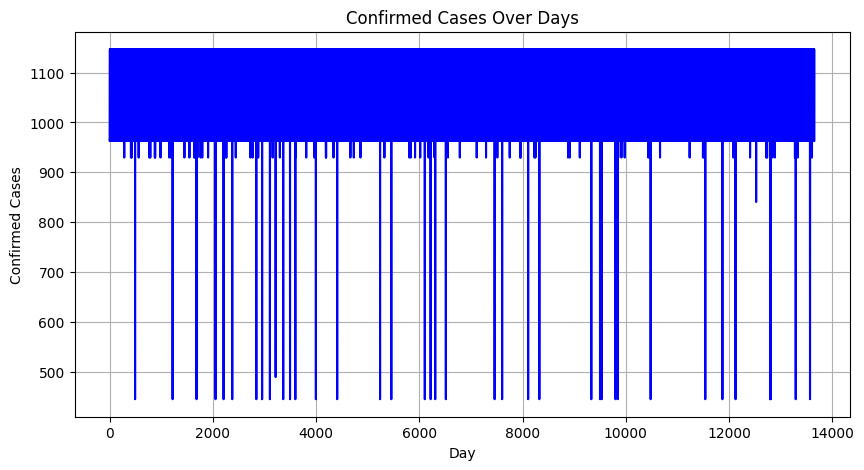

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_pred,y_test, marker='o', linestyle='-', color='blue')  # line with markers
plt.title("Confirmed Cases Over Days")
plt.xlabel("Day")
plt.ylabel("Confirmed Cases")
plt.grid(True)
plt.show()